## PLUTO Zoning Composition By NTA

This notebook builds an NTA heatmap from PLUTO zoning district fields. It uses whichever `zonedist` columns are available in the local PLUTO extract and works best after refreshing the download with the updated query.

In [1]:
import re
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd()
if cwd.name == "notebooks":
    sys.path.insert(0, str(cwd.parent))
else:
    sys.path.insert(0, str(cwd))

from helpers import  prep_zone_data


In [4]:
GROUP_ORDER = [
    "Residential",
    "Commercial",
    "Manufacturing",
    "Special Purpose / Other",
    "Unknown",
]


In [2]:
pluto_with_nta, zoning_long, available_zoning_columns = prep_zone_data()

Using zoning columns: ['zonedist1', 'zonedist2']


In [5]:
nta_zoning = (
    zoning_long
    .groupby(["nta_id", "nta_name", "borough", "zoning_group"], as_index=False)["allocated_lotarea"]
    .sum()
)

nta_totals = (
    nta_zoning
    .groupby(["nta_id", "nta_name", "borough"], as_index=False)["allocated_lotarea"]
    .sum()
    .rename(columns={"allocated_lotarea": "nta_total_lotarea"})
)

nta_zoning_pct = nta_zoning.merge(nta_totals, on=["nta_id", "nta_name", "borough"], how="left")
nta_zoning_pct["pct_lotarea"] = np.where(
    nta_zoning_pct["nta_total_lotarea"] > 0,
    100 * nta_zoning_pct["allocated_lotarea"] / nta_zoning_pct["nta_total_lotarea"],
    0,
)

heatmap_df = (
    nta_zoning_pct
    .pivot_table(
        index=["borough", "nta_name"],
        columns="zoning_group",
        values="pct_lotarea",
        fill_value=0,
    )
    .reindex(columns=GROUP_ORDER, fill_value=0)
    .sort_index()
)

heatmap_df.head(10)


zoning_group                                Residential  Commercial  \
borough nta_name                                                      
Bronx   Allerton                              90.037705    8.770331   
        Bedford Park                          89.937508    4.327444   
        Belmont                               85.994162   11.153376   
        Bronx Park                             0.665921    0.006338   
        Castle Hill-Unionport                 65.205863    4.290327   
        Claremont Park                         0.000000    0.000000   
        Claremont Village-Claremont (East)    59.420443    2.718807   
        Co-op City                            60.415511   25.405935   
        Concourse-Concourse Village           54.405370   24.357562   
        Crotona Park                           0.000000    0.000000   

zoning_group                                Manufacturing  \
borough nta_name                                            
Bronx   Allerton                                 0.000000   
        Bedford Park                             0.867402   
        Belmont                                  1.531808   
        Bronx Park                               0.000000   
        Castle Hill-Unionport                   29.626775   
        Claremont Park                           0.000000   
        Claremont Village-Claremont (East)      37.219416   
        Co-op City                              13.430523   
        Concourse-Concourse Village             11.652373   
        Crotona Park                             0.000000   

zoning_group                                Special Purpose / Other   Unknown  
borough nta_name                                                               
Bronx   Allerton                                           1.191964  0.000000  
        Bedford Park                                       4.840320  0.027326  
        Belmont                                            1.213104  0.107549  
        Bronx Park                                        99.327741  0.000000  
        Castle Hill-Unionport                              0.857629  0.019406  
        Claremont Park                                   100.000000  0.000000  
        Claremont Village-Claremont (East)                 0.641334  0.000000  
        Co-op City                                         0.748031  0.000000  
        Concourse-Concourse Village                        9.358421  0.226274  
        Crotona Park                                     100.000000  0.000000

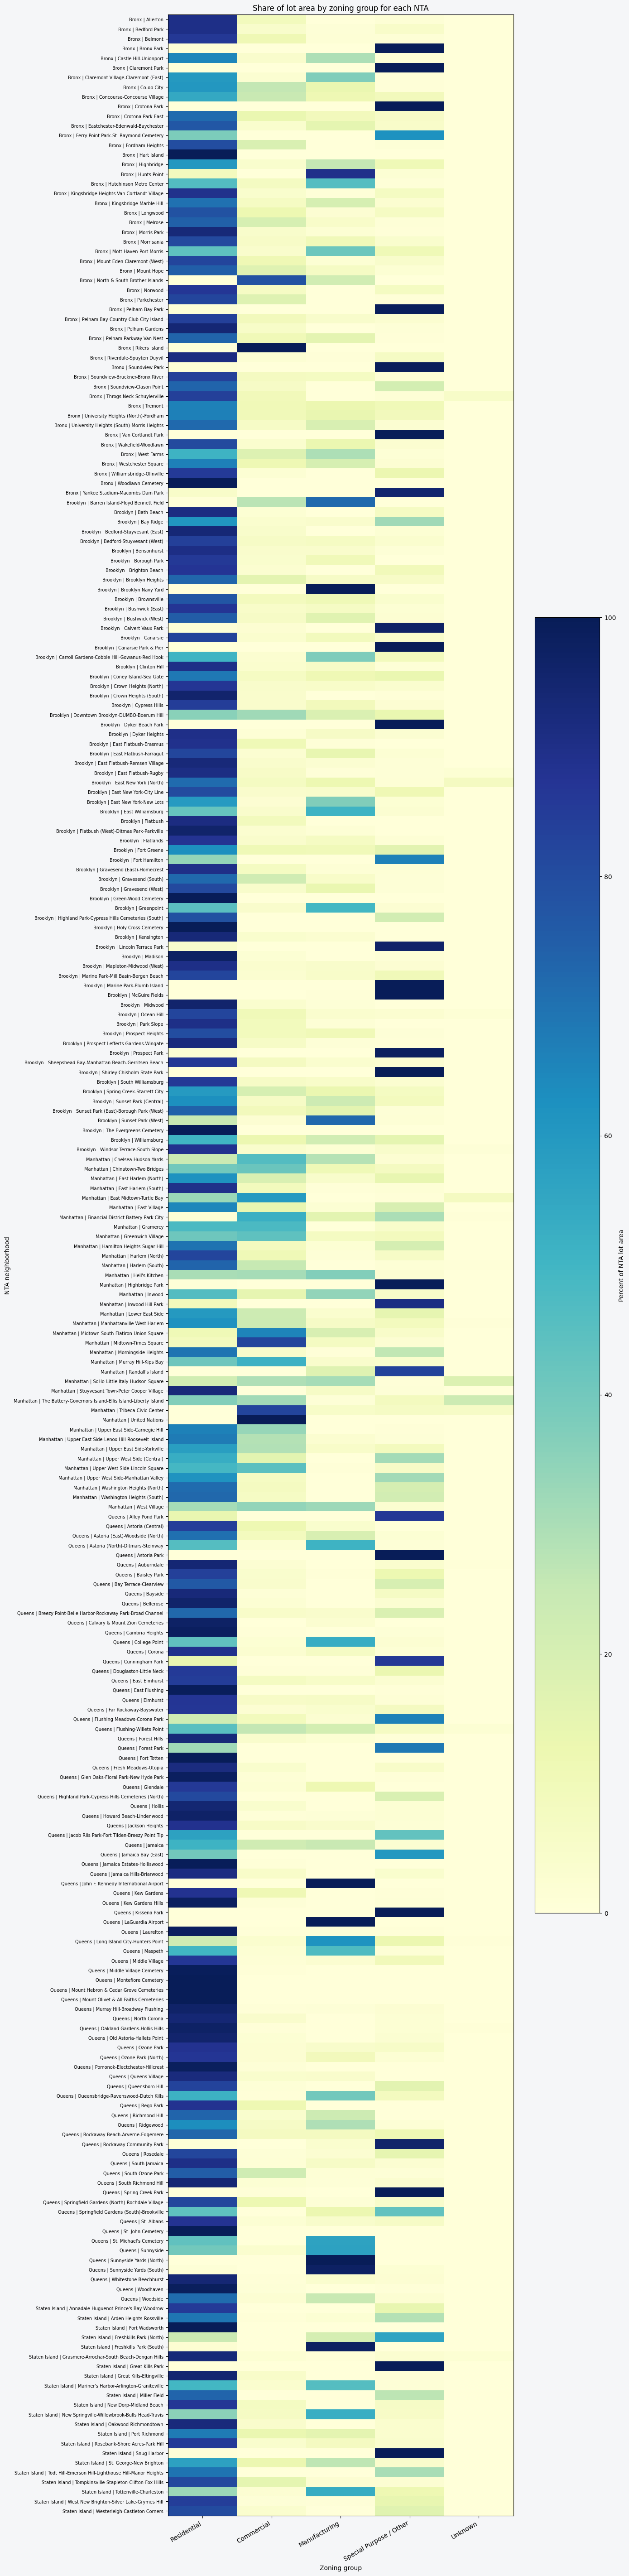

In [6]:
row_labels = [f"{borough} | {nta}" for borough, nta in heatmap_df.index]
height = max(8, 0.22 * len(row_labels))

fig, ax = plt.subplots(figsize=(14, height), facecolor="#F5F6F8")
ax.set_facecolor("#FFFFFF")

im = ax.imshow(heatmap_df.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=7)
ax.set_xlabel("Zoning group")
ax.set_ylabel("NTA neighborhood")
ax.set_title("Share of lot area by zoning group for each NTA")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Percent of NTA lot area")

plt.tight_layout()
plt.show()


In [7]:
dominant_zoning = (
    nta_zoning_pct
    .sort_values(["nta_id", "pct_lotarea"], ascending=[True, False])
    .groupby(["nta_id", "nta_name", "borough"], as_index=False)
    .first()[["nta_id", "nta_name", "borough", "zoning_group", "pct_lotarea"]]
    .rename(columns={
        "zoning_group": "dominant_zoning_group",
        "pct_lotarea": "dominant_zoning_pct_lotarea",
    })
    .sort_values(["borough", "nta_name"])
    .reset_index(drop=True)
)

dominant_zoning.head(20)


,nta_id,nta_name,borough,dominant_zoning_group,dominant_zoning_pct_lotarea
0,BX1104,Allerton,Bronx,Residential,90.037705
1,BX0702,Bedford Park,Bronx,Residential,89.937508
2,BX0603,Belmont,Bronx,Residential,85.994162
3,BX2791,Bronx Park,Bronx,Special Purpose / Other,99.327741
4,BX0903,Castle Hill-Unionport,Bronx,Residential,65.205863
5,BX0492,Claremont Park,Bronx,Special Purpose / Other,100.000000
6,BX0302,Claremont Village-Claremont (East),Bronx,Residential,59.420443
7,BX1004,Co-op City,Bronx,Residential,60.415511
8,BX0401,Concourse-Concourse Village,Bronx,Residential,54.405370
9,BX0391,Crotona Park,Bronx,Special Purpose / Other,100.000000
